In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

In [ ]:
df = pd.read_csv(r"C:\Users\dhanu\Downloads\insurance_data.csv")
df.head()

,age,bought_insurance
0,22,0
1,25,0
2,47,1
3,52,0
4,46,1


In [3]:
X_train, X_test, y_train, y_test = train_test_split(df[['age']],df.bought_insurance,train_size=0.8)
X_test

,age
6,55
10,18
16,25
17,58
15,55
9,61


In [4]:
model = LogisticRegression()
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [5]:
y_predict = model.predict(X_test)
model.predict_proba(X_test)

array([[0.02982774, 0.97017226],
       [0.99214525, 0.00785475],
       [0.96319238, 0.03680762],
       [0.01541783, 0.98458217],
       [0.02982774, 0.97017226],
       [0.00791263, 0.99208737]])

In [6]:
model.score(X_test,y_test)
y_predict

array([1, 0, 0, 1, 1, 1])

In [7]:
X_test

,age
6,55
10,18
16,25
17,58
15,55
9,61


In [8]:
model.coef_

array([[0.2248861]])

In [9]:
model.intercept_

array([-8.88670062])

In [10]:
import math
def sigmoid(x):
  return 1 / (1 + math.exp(-x))

In [11]:
def prediction_function(age):
    z = 0.042 * age - 1.53 # 0.04150133 ~ 0.042 and -1.52726963 ~ -1.53
    y = sigmoid(z)
    return y

In [12]:
age = 35
prediction_function(age)

0.4850044983805899

In [13]:
age = 43
prediction_function(age)

0.568565299077705

Text(0.5, 1.0, 'Linear Regression')

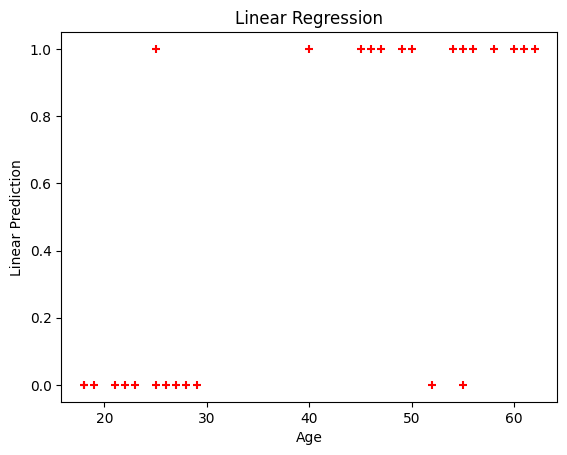

In [14]:
plt.scatter(df.age,df.bought_insurance,marker='+',color='red')
plt.xlabel("Age")
plt.ylabel("Linear Prediction")
plt.title("Linear Regression")

c:\Users\dhanu\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


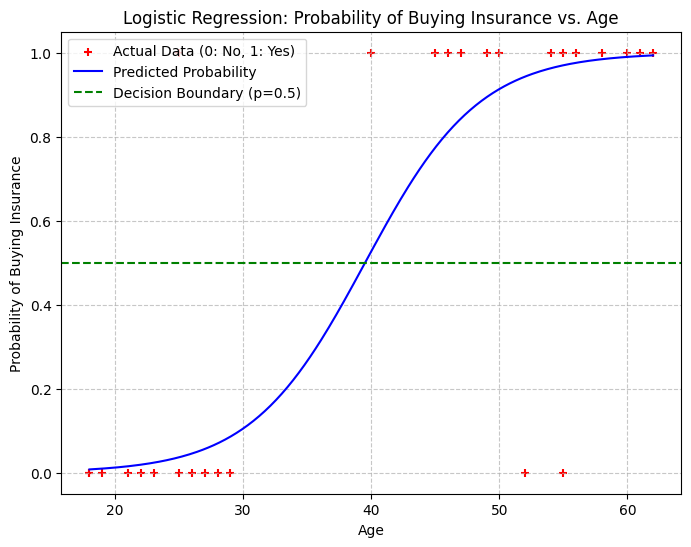

In [15]:
# Generate a range of ages for plotting the logistic curve
ages_for_plot = np.linspace(df['age'].min(), df['age'].max(), 300).reshape(-1, 1)

# Predict probabilities for these ages
probabilities = model.predict_proba(ages_for_plot)[:, 1] # Get probability of class 1 (bought insurance)

plt.figure(figsize=(8, 6))

# Plot the original data points
plt.scatter(df.age, df.bought_insurance, marker='+', color='red', label='Actual Data (0: No, 1: Yes)')

# Plot the logistic regression curve
plt.plot(ages_for_plot, probabilities, color='blue', label='Predicted Probability')

# Add a horizontal line for the decision boundary (p=0.5)
plt.axhline(y=0.5, color='green', linestyle='--', label='Decision Boundary (p=0.5)')

plt.title('Logistic Regression: Probability of Buying Insurance vs. Age')
plt.xlabel('Age')
plt.ylabel('Probability of Buying Insurance')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()

c:\Users\dhanu\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


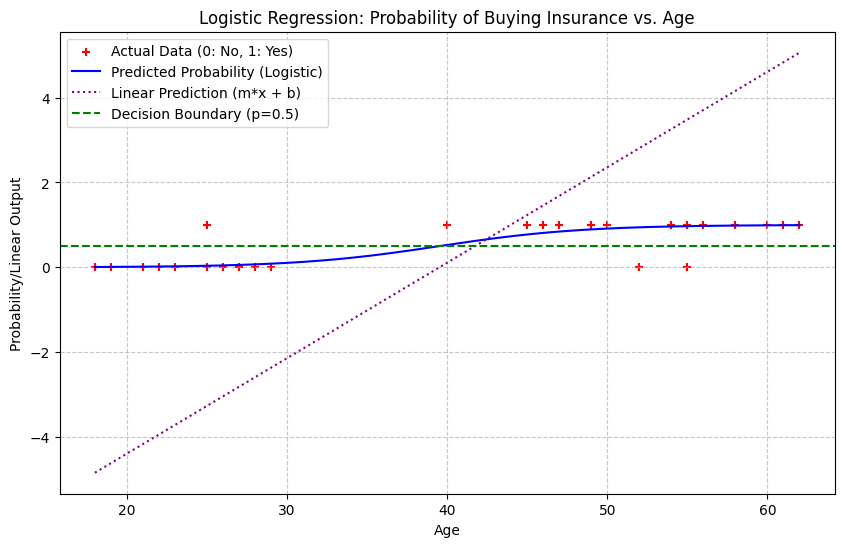

In [16]:
# Generate a range of ages for plotting the logistic curve
ages_for_plot = np.linspace(df['age'].min(), df['age'].max(), 300).reshape(-1, 1)

# Predict probabilities for these ages (for the logistic curve)
probability = model.predict_proba(ages_for_plot)[:, 1] # Get probability of class 1 (bought insurance)

plt.figure(figsize=(10, 6))

# Plot the original data points
plt.scatter(df.age, df.bought_insurance, marker='+', color='red', label='Actual Data (0: No, 1: Yes)')

# Plot the logistic regression curve
plt.plot(ages_for_plot, probability, color='blue', label='Predicted Probability (Logistic)')

# Calculate the linear part of the logistic function (m*x + b)
linear_predict = model.coef_[0][0] * ages_for_plot + model.intercept_[0]
plt.plot(ages_for_plot, linear_predict, color='purple', linestyle=':', label='Linear Prediction (m*x + b)')

# Add a horizontal line for the decision boundary (p=0.5)
plt.axhline(y=0.5, color='green', linestyle='--', label='Decision Boundary (p=0.5)')

plt.title('Logistic Regression: Probability of Buying Insurance vs. Age')
plt.xlabel('Age')
plt.ylabel('Probability/Linear Output')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()